1: Load Dataset

In [4]:

import pandas as pd

retail_sales = pd.read_csv("retail_sales_dataset.csv")
retail_sales.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Chek the missing values 

In [8]:
retail_sales.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

###  Observation
***No significant missing values were found in the dataset.***

### 3: Descriptive Statistics

In [13]:
retail_sales.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


retail The average purchase amount is X.

The maximum purchase amount is Y.

In [15]:
print("Average Purchase Amount:", retail_sales['Total Amount'].mean())
print("Maximum Purchase Amount:", retail_sales['Total Amount'].max())

Average Purchase Amount: 456.0
Maximum Purchase Amount: 2000


***Mean (Average) = x = The average amount of money customers spend.***

***Maximum = y = The value of the largest purchase made***

In [25]:
customer_data = retail_sales.groupby('Customer ID').agg({
    'Total Amount':'sum',
    'Transaction ID':'count',
    'Quantity':'sum'
}).reset_index()

customer_data.columns = [
    'CustomerID',
    'Monetary',
    'Frequency',
    'Quantity'
]

customer_data.head()

,CustomerID,Monetary,Frequency,Quantity
0,CUST001,150,1,3
1,CUST002,1000,1,2
2,CUST003,30,1,1
3,CUST004,500,1,1
4,CUST005,100,1,2


****Feature of meaning****

***Monetary	Total Money Spent***

***Frequency	Number of Purchases***

***Quantity	Total Items Bought***

### Feature Selection

Three behavr l features were selected for clustering:

1. Monetary – Total amount spent by the customer.
2. Frequency – Number of transactions made by the customer.
3. Quantity – Total number of items purchased.

These features represent customer purchasing behaviour and are suitable for customer segmentation using K-Means clustering.

In [37]:
## customer_data.head()
features = customer_data[
    ['Monetary','Frequency','Quantity']
]

### Standardization

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [ ]:
## Elbow Method

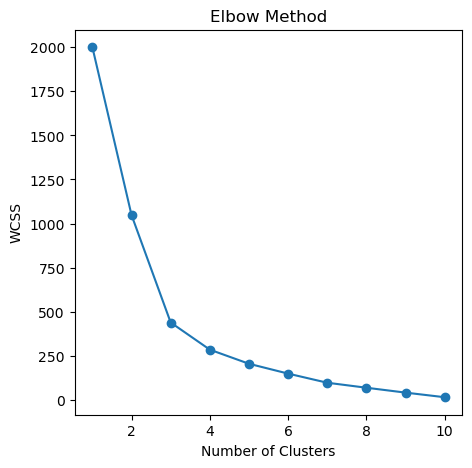

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(5,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show() 

### Elbow Method Observation
***
The WCSS value decreases quickly from K=1 to K=***3.***

After K=3, the decrease becomes s***lo***w.

This shows that K=3 is the best number of clusters for the da***ta***set.

Therefore, K=3 was selected for customer segm***ntation.

####  Apply KMeans

In [57]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

customer_data['Cluster'] = kmeans.fit_predict(
    scaled_features
)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


### Scatter Plot
Frequency vs Monetary

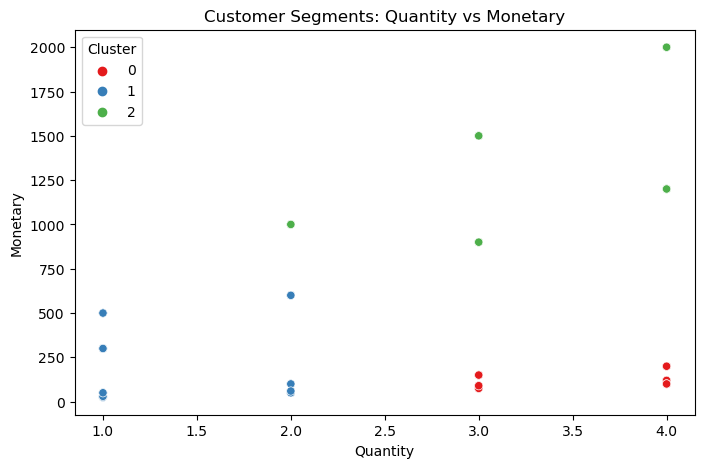

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customer_data,
    x='Quantity',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments: Quantity vs Monetary")

plt.show()

Quantity vs Monetary

### Observation

The scatter plot compares Quantity purchased and Monetary value spent by customers.

The X-axis represents the number of products purchased, while the Y-axis represents the total amount spent.

Customers are divided into three clusters:

- Cluster 0 (Red): Low-spending customers.
- Cluster 1 (Blue): Medium-spending customers.
- Cluster 2 (Green): High-spending customers.

The graph helps identify valuable customers who contribute the most revenue to the business.

Bar chart

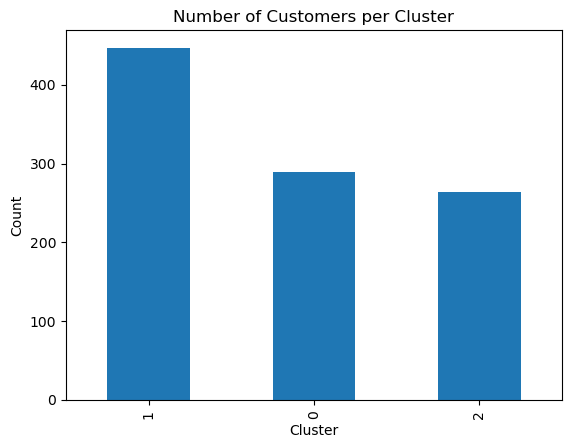

In [66]:
customer_data['Cluster'].value_counts().plot(
    kind='bar'
)

plt.title(
    "Number of Customers per Cluster"
)

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()

### Observation

The bar chart shows the distribution of customers across different clusters.

Cluster 1 contains the highest number of customers, making it the largest customer segment.

Cluster 0 contains a moderate number of customers.

Cluster 2 contains the smallest number of customers.

This distribution helps businesses understand how customers are grouped and allows targeted marketing strategies for each segment.

### Summary

- Cluster 1 → Largest customer group.
- Cluster 0 → Medium-sized customer group.
- Cluster 2 → Smallest customer group.
- The graph helps identify how customers are distributed among different segments.
- Businesses can create different marketing strategies for each cluster.

In [75]:
cluster_profile = customer_data.groupby('Cluster')[
    ['Monetary','Quantity','Frequency']
].mean()

cluster_profile


,Monetary,Quantity,Frequency
Cluster,,,
0,126.453287,3.553633,1.0
1,171.935123,1.434004,1.0
2,1297.727273,3.204545,1.0


. Profile Each Cluster

In [81]:
cluster_profile = customer_data.groupby('Cluster')[
    ['Monetary','Frequency','Quantity']
].mean()

cluster_profile

,Monetary,Frequency,Quantity
Cluster,,,
0,126.453287,1.0,3.553633
1,171.935123,1.0,1.434004
2,1297.727273,1.0,3.204545


### Bar Chart: Number of Customers per Cluster

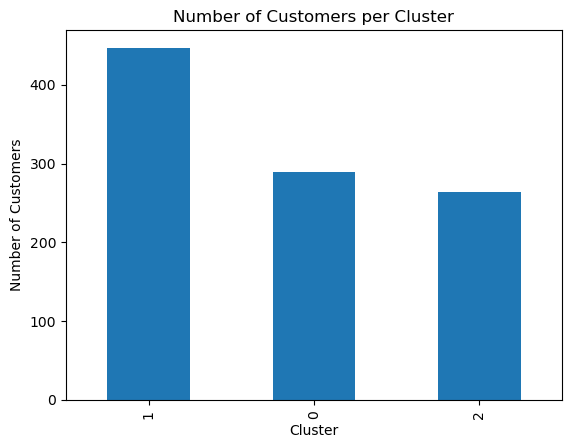

In [85]:
customer_data['Cluster'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Number of Customers per Cluster'
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

### Observation

Cluster 1 contains the highest number of customers, making it the largest customer segment.

Cluster 0 contains a moderate number of customers.

Cluster 2 contains the smallest number of customers.

This distribution helps the business understand customer segmentation and plan targeted marketing strategies.

# Marketing Recommendations

## Cluster 0 - Low Value Customers
These customers spend less money and contribute lower revenue.

Recommended Actions:
- Offer discounts and promotional campaigns.
- Provide special deals to encourage more purchases.

---

## Cluster 1 - Medium Value Customers
These customers have moderate spending behaviour.

Recommended Actions:
- Introduce loyalty programs.
- Offer reward points and membership benefits.

---

## Cluster 2 - High Value Customers
These customers spend the most money and generate the highest revenue.

Recommended Actions:
- Provide VIP memberships.
- Offer personalized recommendations.
- Give exclusive offers and premium services.

---

## Conclusion

Customer segmentation using K-Means successfully divided customers into three distinct groups.

Cluster 0 represents low-value customers.

Cluster 1 represents medium-value customers.

Cluster 2 represents high-value customers.

The business should apply different marketing strategies for each segment to improve customer engagement and maximize revenue.